# Employee Attrition Prediction — Exploratory Data Analysis

Predict whether an IBM employee will leave the company using the IBM HR Analytics Employee Attrition dataset (1,470 employees, 35 features covering demographics, role, compensation, satisfaction).

**Target:** `Attrition` (0 = Stay, 1 = Leave)

## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
df = pd.read_csv('data/employee_attrition.csv')
df = pd.read_csv('data/employee_attrition.csv', encoding='utf-8-sig')
df['Attrition'] = (df['Attrition'] == 'Yes').astype(int)
drop_cols = [c for c in ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'] if c in df.columns]
df = df.drop(columns=drop_cols)
print('Shape:', df.shape)
df.head()

Shape: (1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


## 2. Dataset Overview

In [3]:
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes.value_counts())

Shape: (1470, 31)

Dtypes:
int64     24
object     7
Name: count, dtype: int64


In [4]:
df.describe(include='all').T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470.0,NaN,NaN,NaN,0.161224,0.367863,0.0,0.0,0.0,0.0,1.0
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EnvironmentSatisfaction,1470.0,NaN,NaN,NaN,2.721769,1.093082,1.0,2.0,3.0,4.0,4.0
Gender,1470,2,Male,882,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print('Duplicate rows:', df.duplicated().sum())
print('Memory (MB):', round(df.memory_usage(deep=True).sum() / 1024**2, 2))

Duplicate rows: 0
Memory (MB): 0.85


## 3. Missing / Invalid Values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
if len(missing_df):
    print(missing_df)
else:
    print('No explicit NaN values')

No explicit NaN values


## 4. Target Variable Distribution

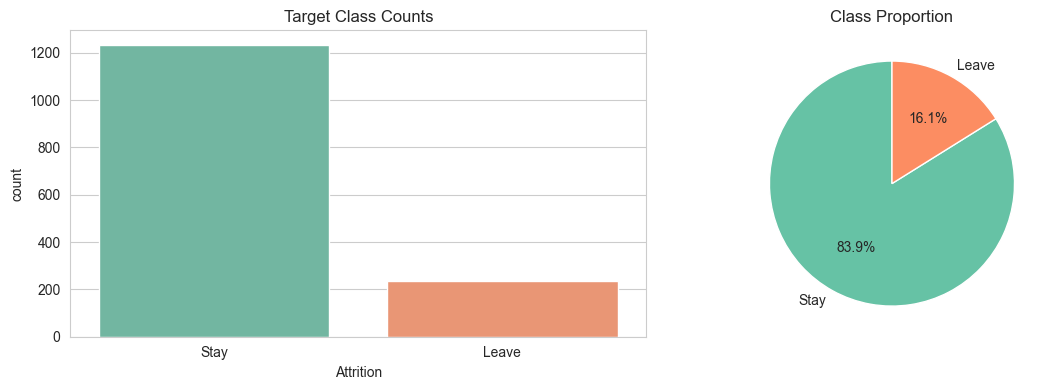


Class balance (%):
Attrition
0    83.88
1    16.12
Name: count, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
target_counts = df['Attrition'].value_counts().sort_index()
sns.countplot(x='Attrition', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Target Class Counts')
axes[0].set_xticklabels(['Stay', 'Leave'])
axes[1].pie(target_counts, labels=['Stay', 'Leave'], autopct='%1.1f%%',
            colors=['#66c2a5', '#fc8d62'], startangle=90)
axes[1].set_title('Class Proportion')
plt.tight_layout(); plt.show()
print('\nClass balance (%):')
print((target_counts / target_counts.sum() * 100).round(2))

## 5. Univariate Analysis — Numeric Features

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Attrition' in numeric_cols:
    numeric_cols.remove('Attrition')
print(f'Numeric features ({len(numeric_cols)}):')
print(numeric_cols)

Numeric features (23):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


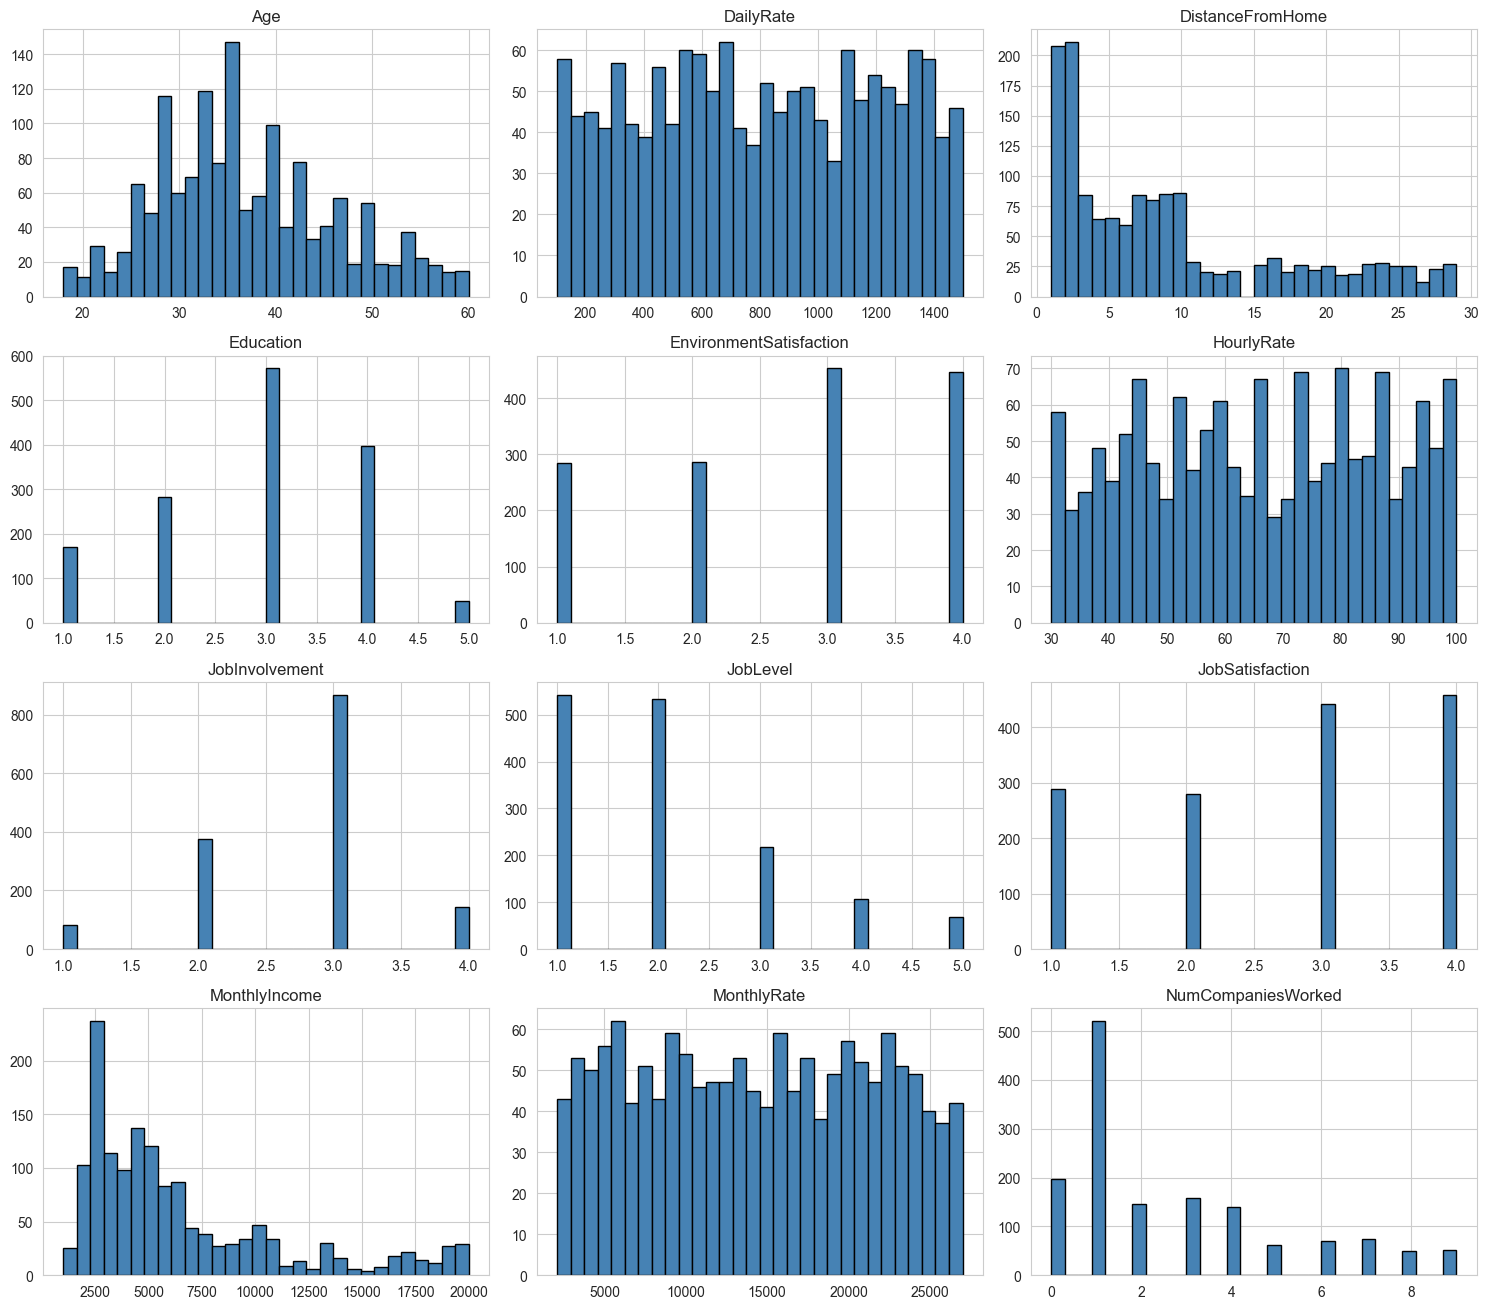

In [9]:
import math
n_show = min(len(numeric_cols), 12)
ncols = 3
nrows = math.ceil(n_show / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.3*nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols[:n_show]):
    df[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

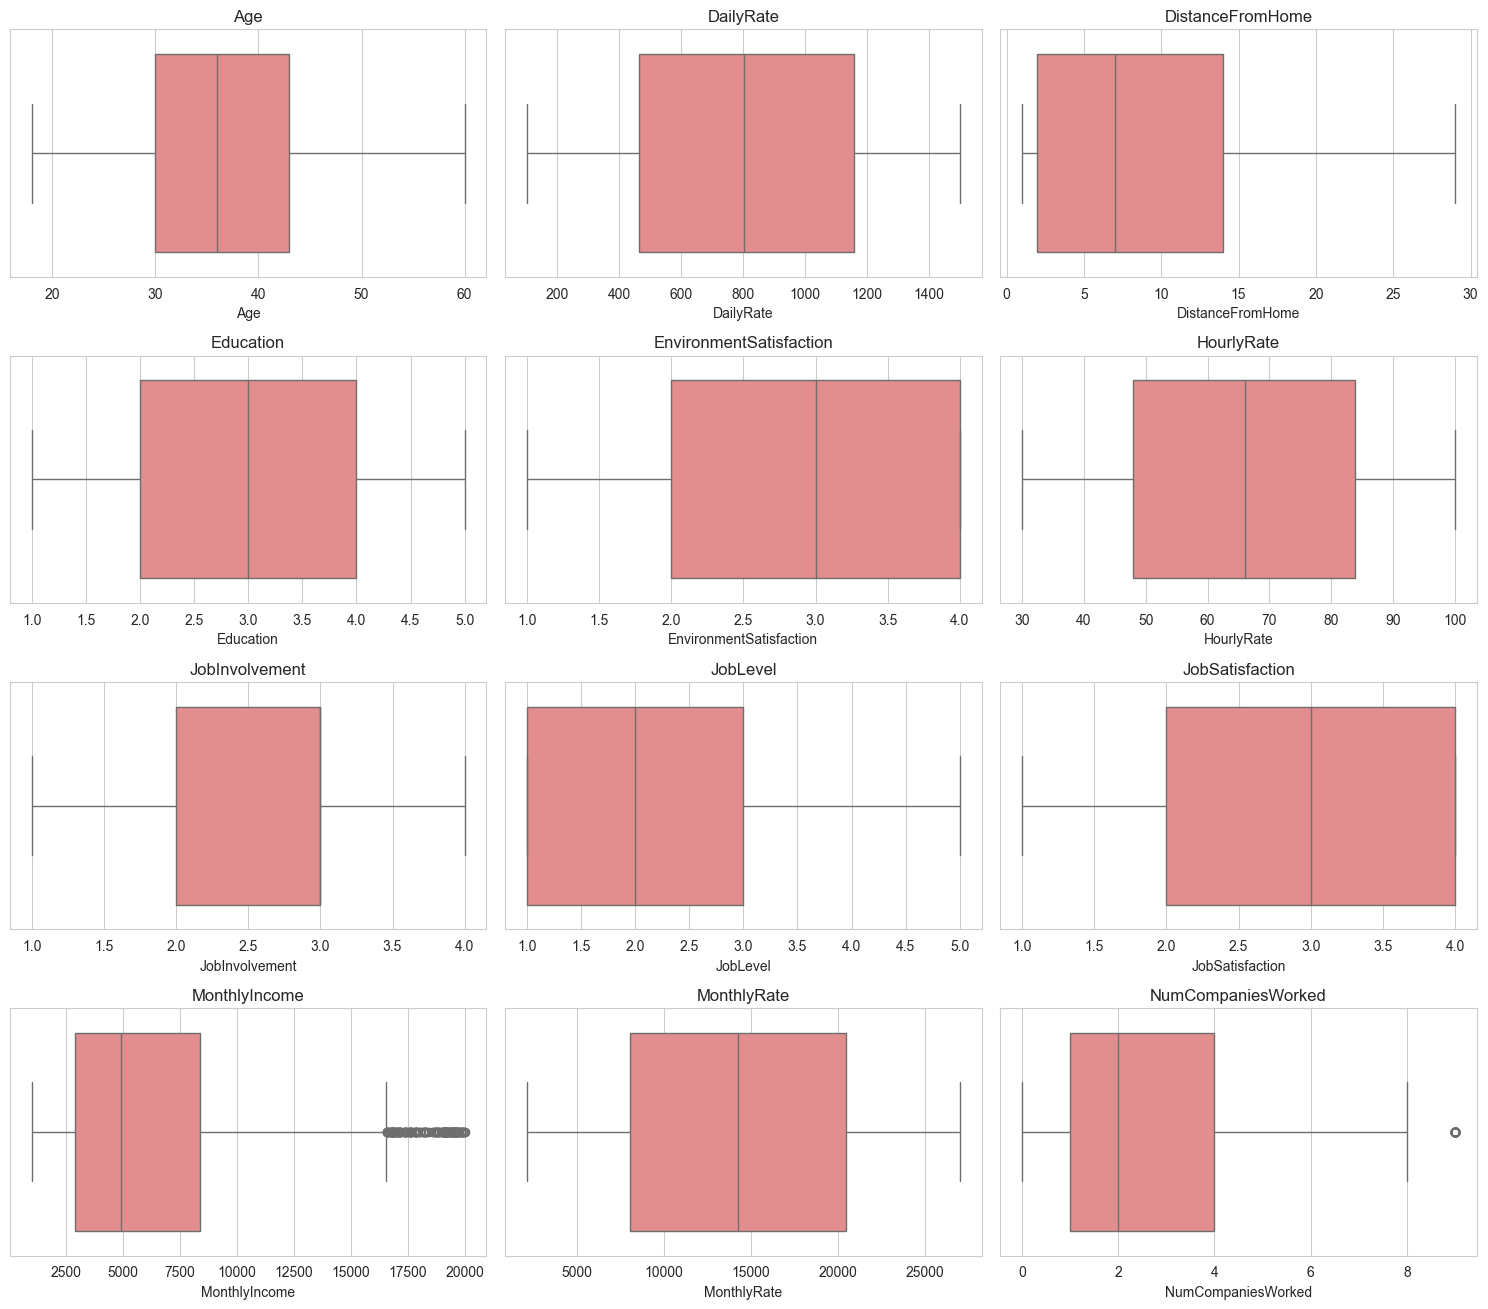

In [10]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.3*nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols[:n_show]):
    sns.boxplot(x=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

## 6. Bivariate Analysis — Features vs Target

In [11]:
corrs_all = df[numeric_cols + ['Attrition']].corr()['Attrition'].abs().sort_values(ascending=False)
top_features = [c for c in corrs_all.index if c != 'Attrition'][:6]
print('Top features by |correlation| with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation| with target:
TotalWorkingYears       0.171
JobLevel                0.169
YearsInCurrentRole      0.161
MonthlyIncome           0.160
Age                     0.159
YearsWithCurrManager    0.156
Name: Attrition, dtype: float64


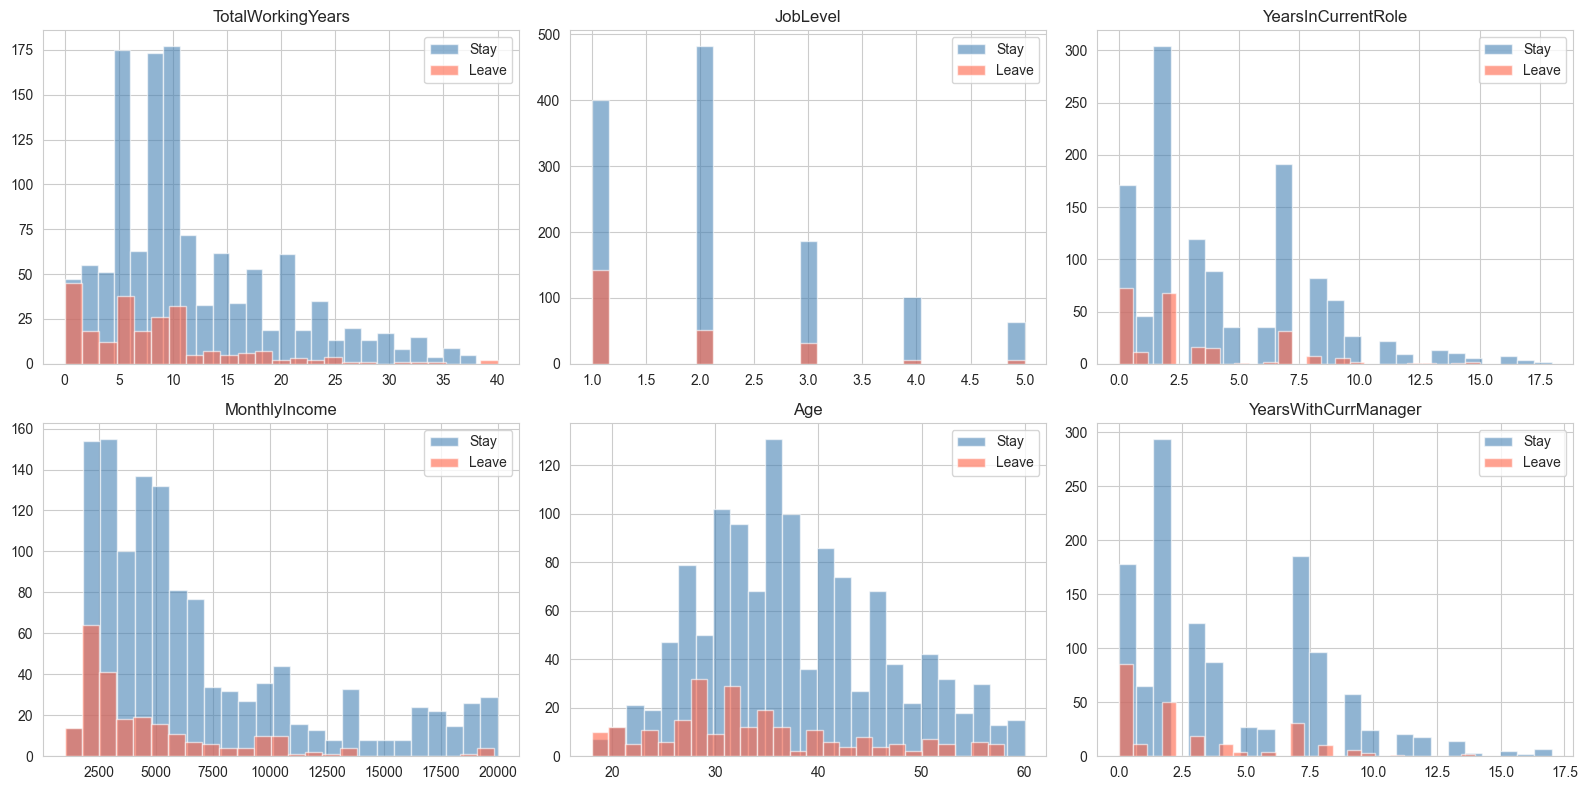

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
labels = ['Stay', 'Leave']
colors = ['steelblue', 'tomato']
for i, col in enumerate(top_features[:6]):
    for cls, lbl, c in [(0, labels[0], colors[0]), (1, labels[1], colors[1])]:
        axes[i].hist(df[df['Attrition']==cls][col].dropna(), bins=25, alpha=0.6, label=lbl, color=c)
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

In [13]:
means = df.groupby('Attrition')[numeric_cols].mean().T
means.columns = ['Stay', 'Leave']
means['Difference'] = means.iloc[:, 1] - means.iloc[:, 0]
means.sort_values('Difference', key=abs, ascending=False).round(3).head(15)

,Stay,Leave,Difference
MonthlyIncome,6832.740,4787.093,-2045.647
MonthlyRate,14265.779,14559.308,293.529
DailyRate,812.504,750.363,-62.142
Age,37.561,33.608,-3.954
TotalWorkingYears,11.863,8.245,-3.618
YearsAtCompany,7.369,5.131,-2.238
DistanceFromHome,8.916,10.633,1.717
YearsInCurrentRole,4.484,2.903,-1.581
YearsWithCurrManager,4.367,2.852,-1.515
JobLevel,2.146,1.637,-0.509


## 7. Correlation Analysis

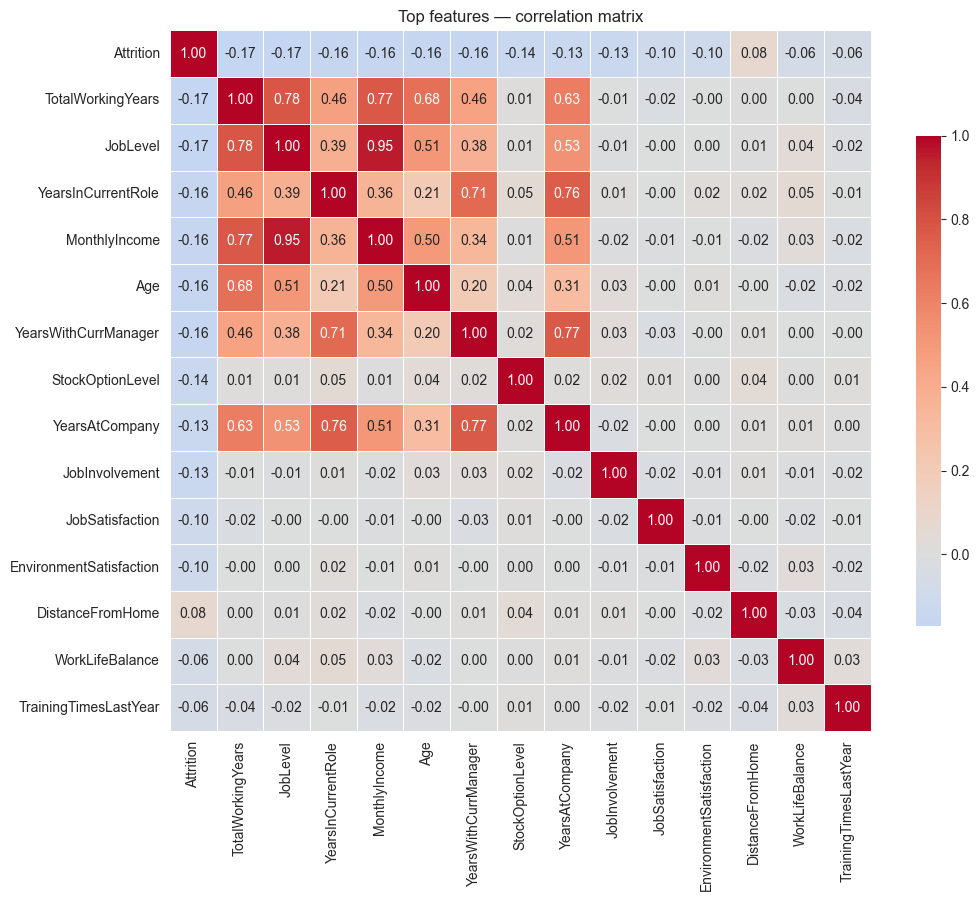

In [14]:
# Restrict to top numeric features for legibility
top_numeric = corrs_all.head(15).index.tolist()
if 'Attrition' not in top_numeric:
    top_numeric.append('Attrition')
corr_matrix = df[top_numeric].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix'); plt.tight_layout(); plt.show()

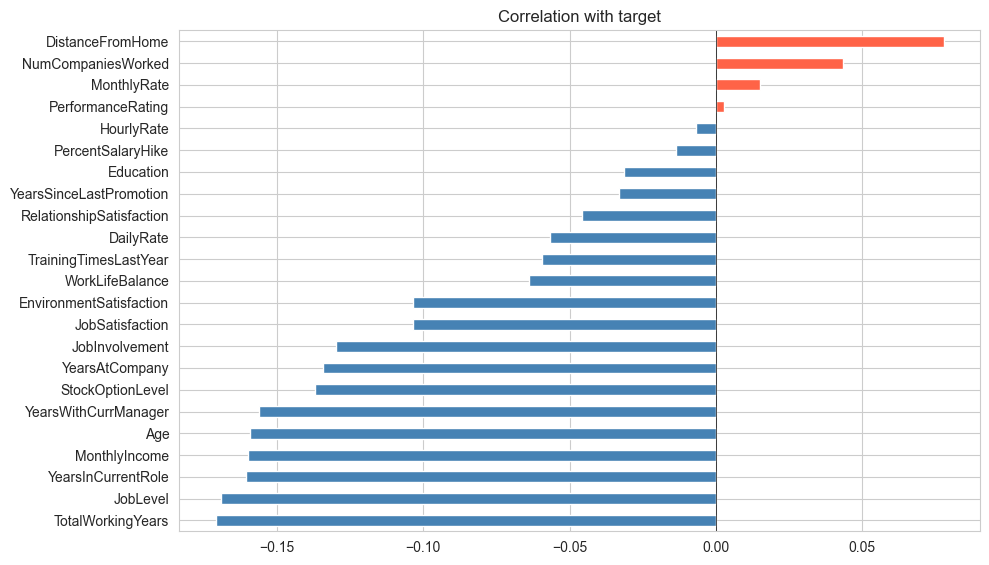

In [15]:
target_corr = df[numeric_cols + ['Attrition']].corr()['Attrition'].drop('Attrition').sort_values()
plt.figure(figsize=(10, max(5, len(target_corr)*0.25)))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.title('Correlation with target')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout(); plt.show()

## 8. Domain Deep-Dive — HR Drivers of Attrition

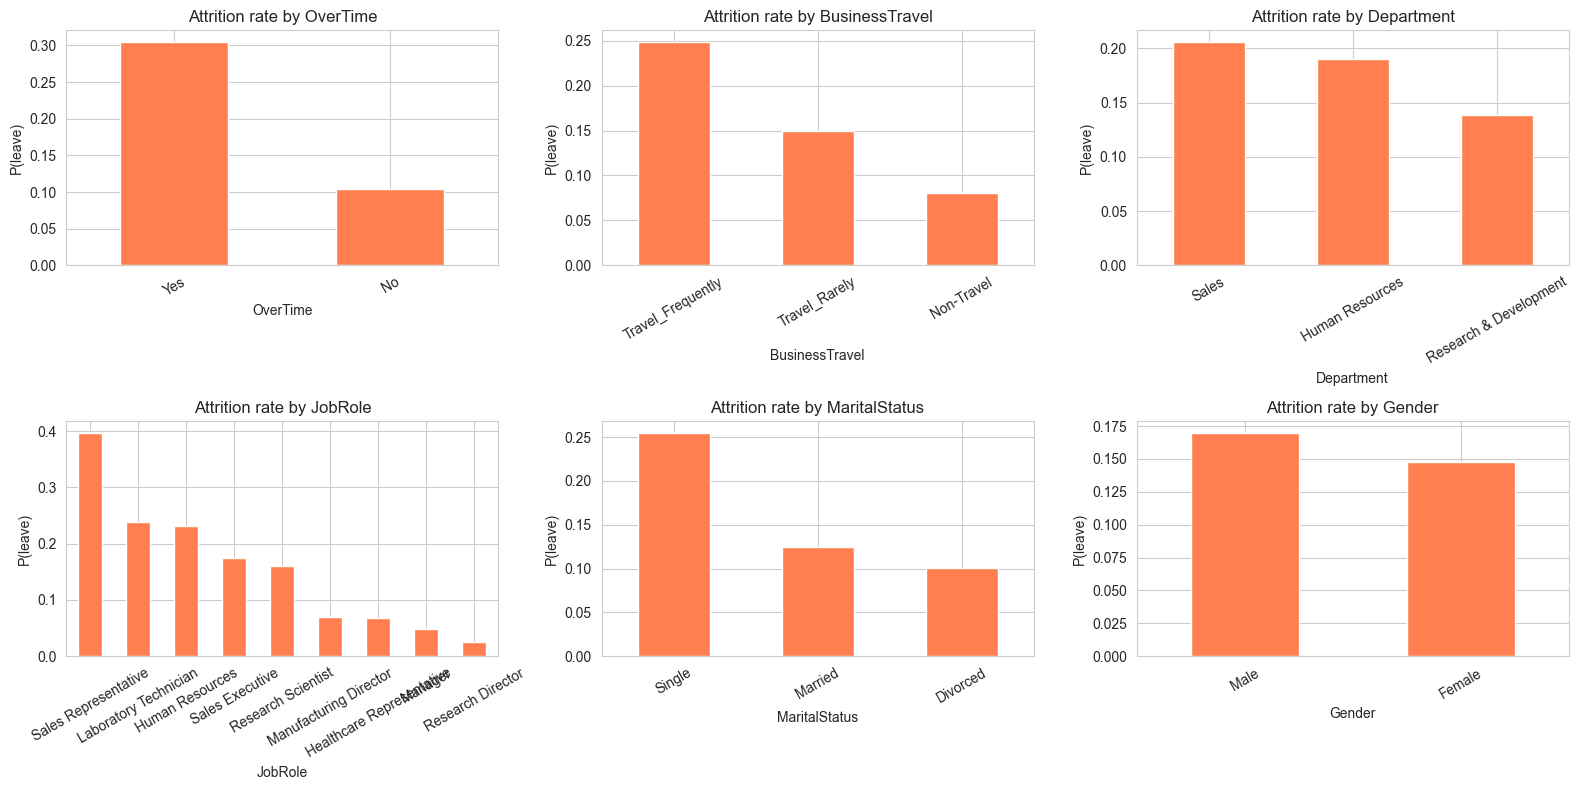

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
cat_features = ['OverTime', 'BusinessTravel', 'Department', 'JobRole', 'MaritalStatus', 'Gender']
for i, col in enumerate(cat_features):
    rate = df.groupby(col)['Attrition'].mean().sort_values(ascending=False)
    rate.plot(kind='bar', ax=axes[i], color='coral')
    axes[i].set_title(f'Attrition rate by {col}'); axes[i].set_ylabel('P(leave)')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

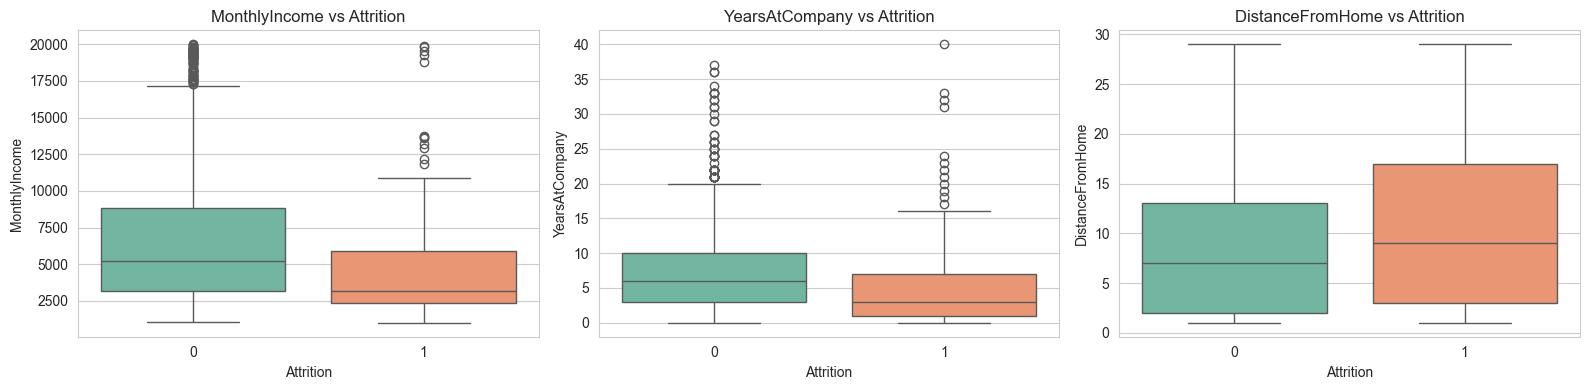

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['MonthlyIncome', 'YearsAtCompany', 'DistanceFromHome']):
    sns.boxplot(x='Attrition', y=col, data=df, ax=ax, palette='Set2')
    ax.set_title(f'{col} vs Attrition')
plt.tight_layout(); plt.show()

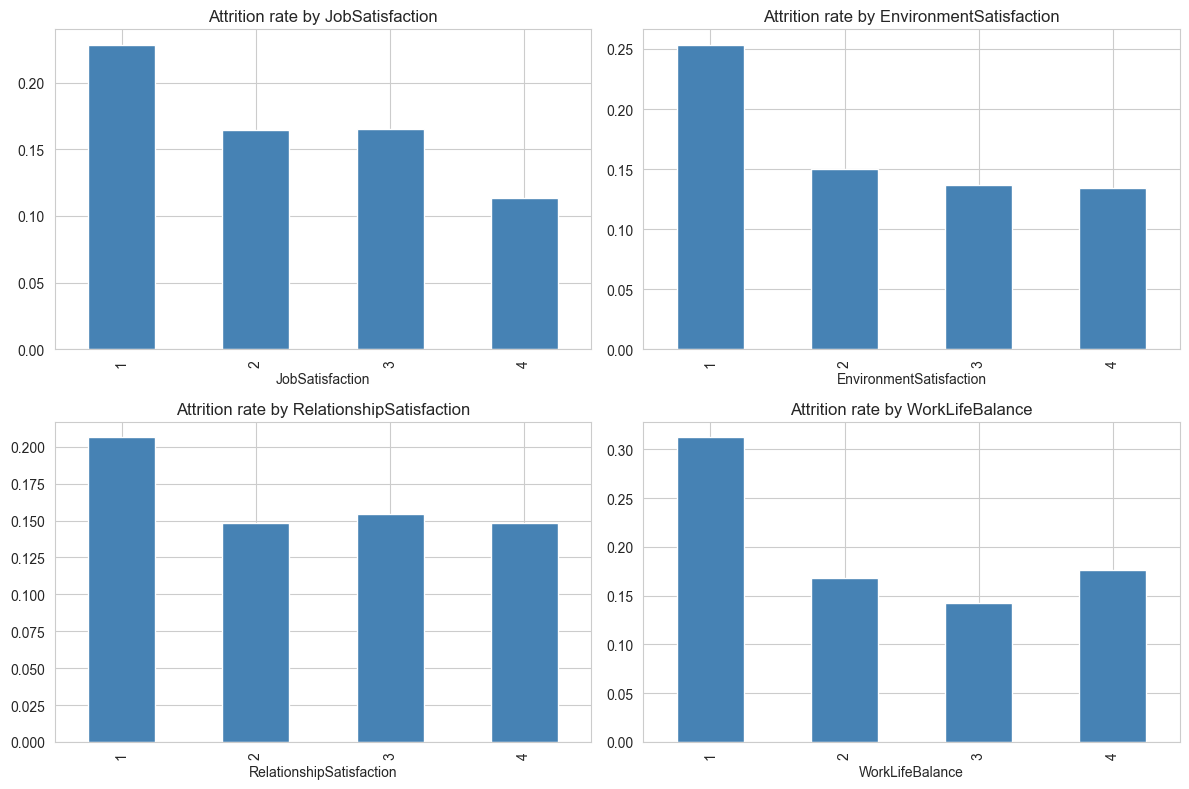

In [18]:
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
                     'RelationshipSatisfaction', 'WorkLifeBalance']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(satisfaction_cols):
    rate = df.groupby(col)['Attrition'].mean()
    rate.plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Attrition rate by {col}')
plt.tight_layout(); plt.show()

## 9. Pair Plot of Top Features

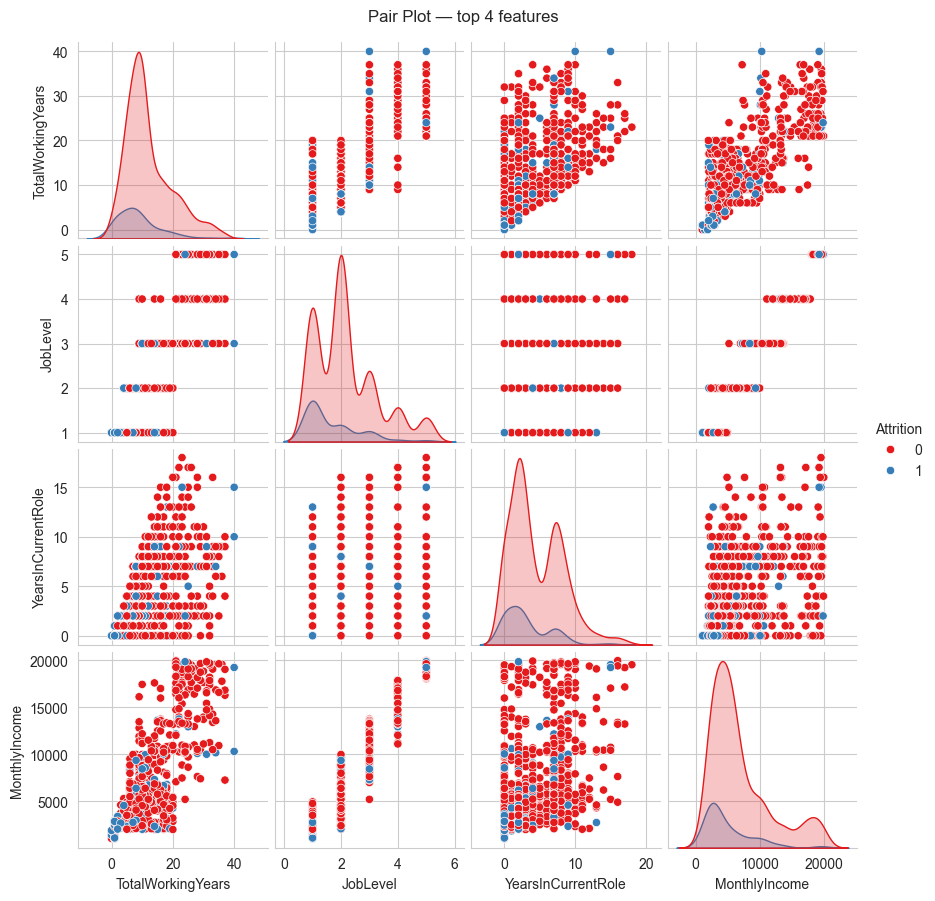

In [19]:
sample = df.sample(min(1000, len(df)), random_state=42)
sns.pairplot(sample[top_features[:4] + ['Attrition']].dropna(),
             hue='Attrition', palette='Set1', diag_kind='kde', height=2.2)
plt.suptitle('Pair Plot — top 4 features', y=1.02); plt.show()

## 10. Summary of Key Findings

In [20]:
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Class 0 count', 'Class 1 count',
               'Class imbalance ratio', 'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df),
        df.shape[1] - 1,
        int((df['Attrition'] == 0).sum()),
        int((df['Attrition'] == 1).sum()),
        f"{(df['Attrition'] == 0).sum() / max(1, (df['Attrition'] == 1).sum()):.2f}:1",
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,1470
1,Total features,30
2,Class 0 count,1233
3,Class 1 count,237
4,Class imbalance ratio,5.20:1
5,Top correlated feature,TotalWorkingYears
6,Top correlation value,0.171
